## Loading the libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Load the Boston House Pricing dataset

In [4]:
dataset = pd.read_csv("Boston Dataset.csv")
dataset.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
dataset.columns = dataset.columns.str.upper()
dataset.rename(columns={"MEDV": "Price"}, inplace=True)
dataset.head()

,UNNAMED: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT,Price
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
dataset = dataset.iloc[:,1:]
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  BLACK    506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [8]:
# Summarizing the stats of data
dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
# Check the missing value
dataset.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
BLACK      0
LSTAT      0
Price      0
dtype: int64

In [10]:
# Exploratory Data Analysis
## Correlation
dataset.corr()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT,Price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


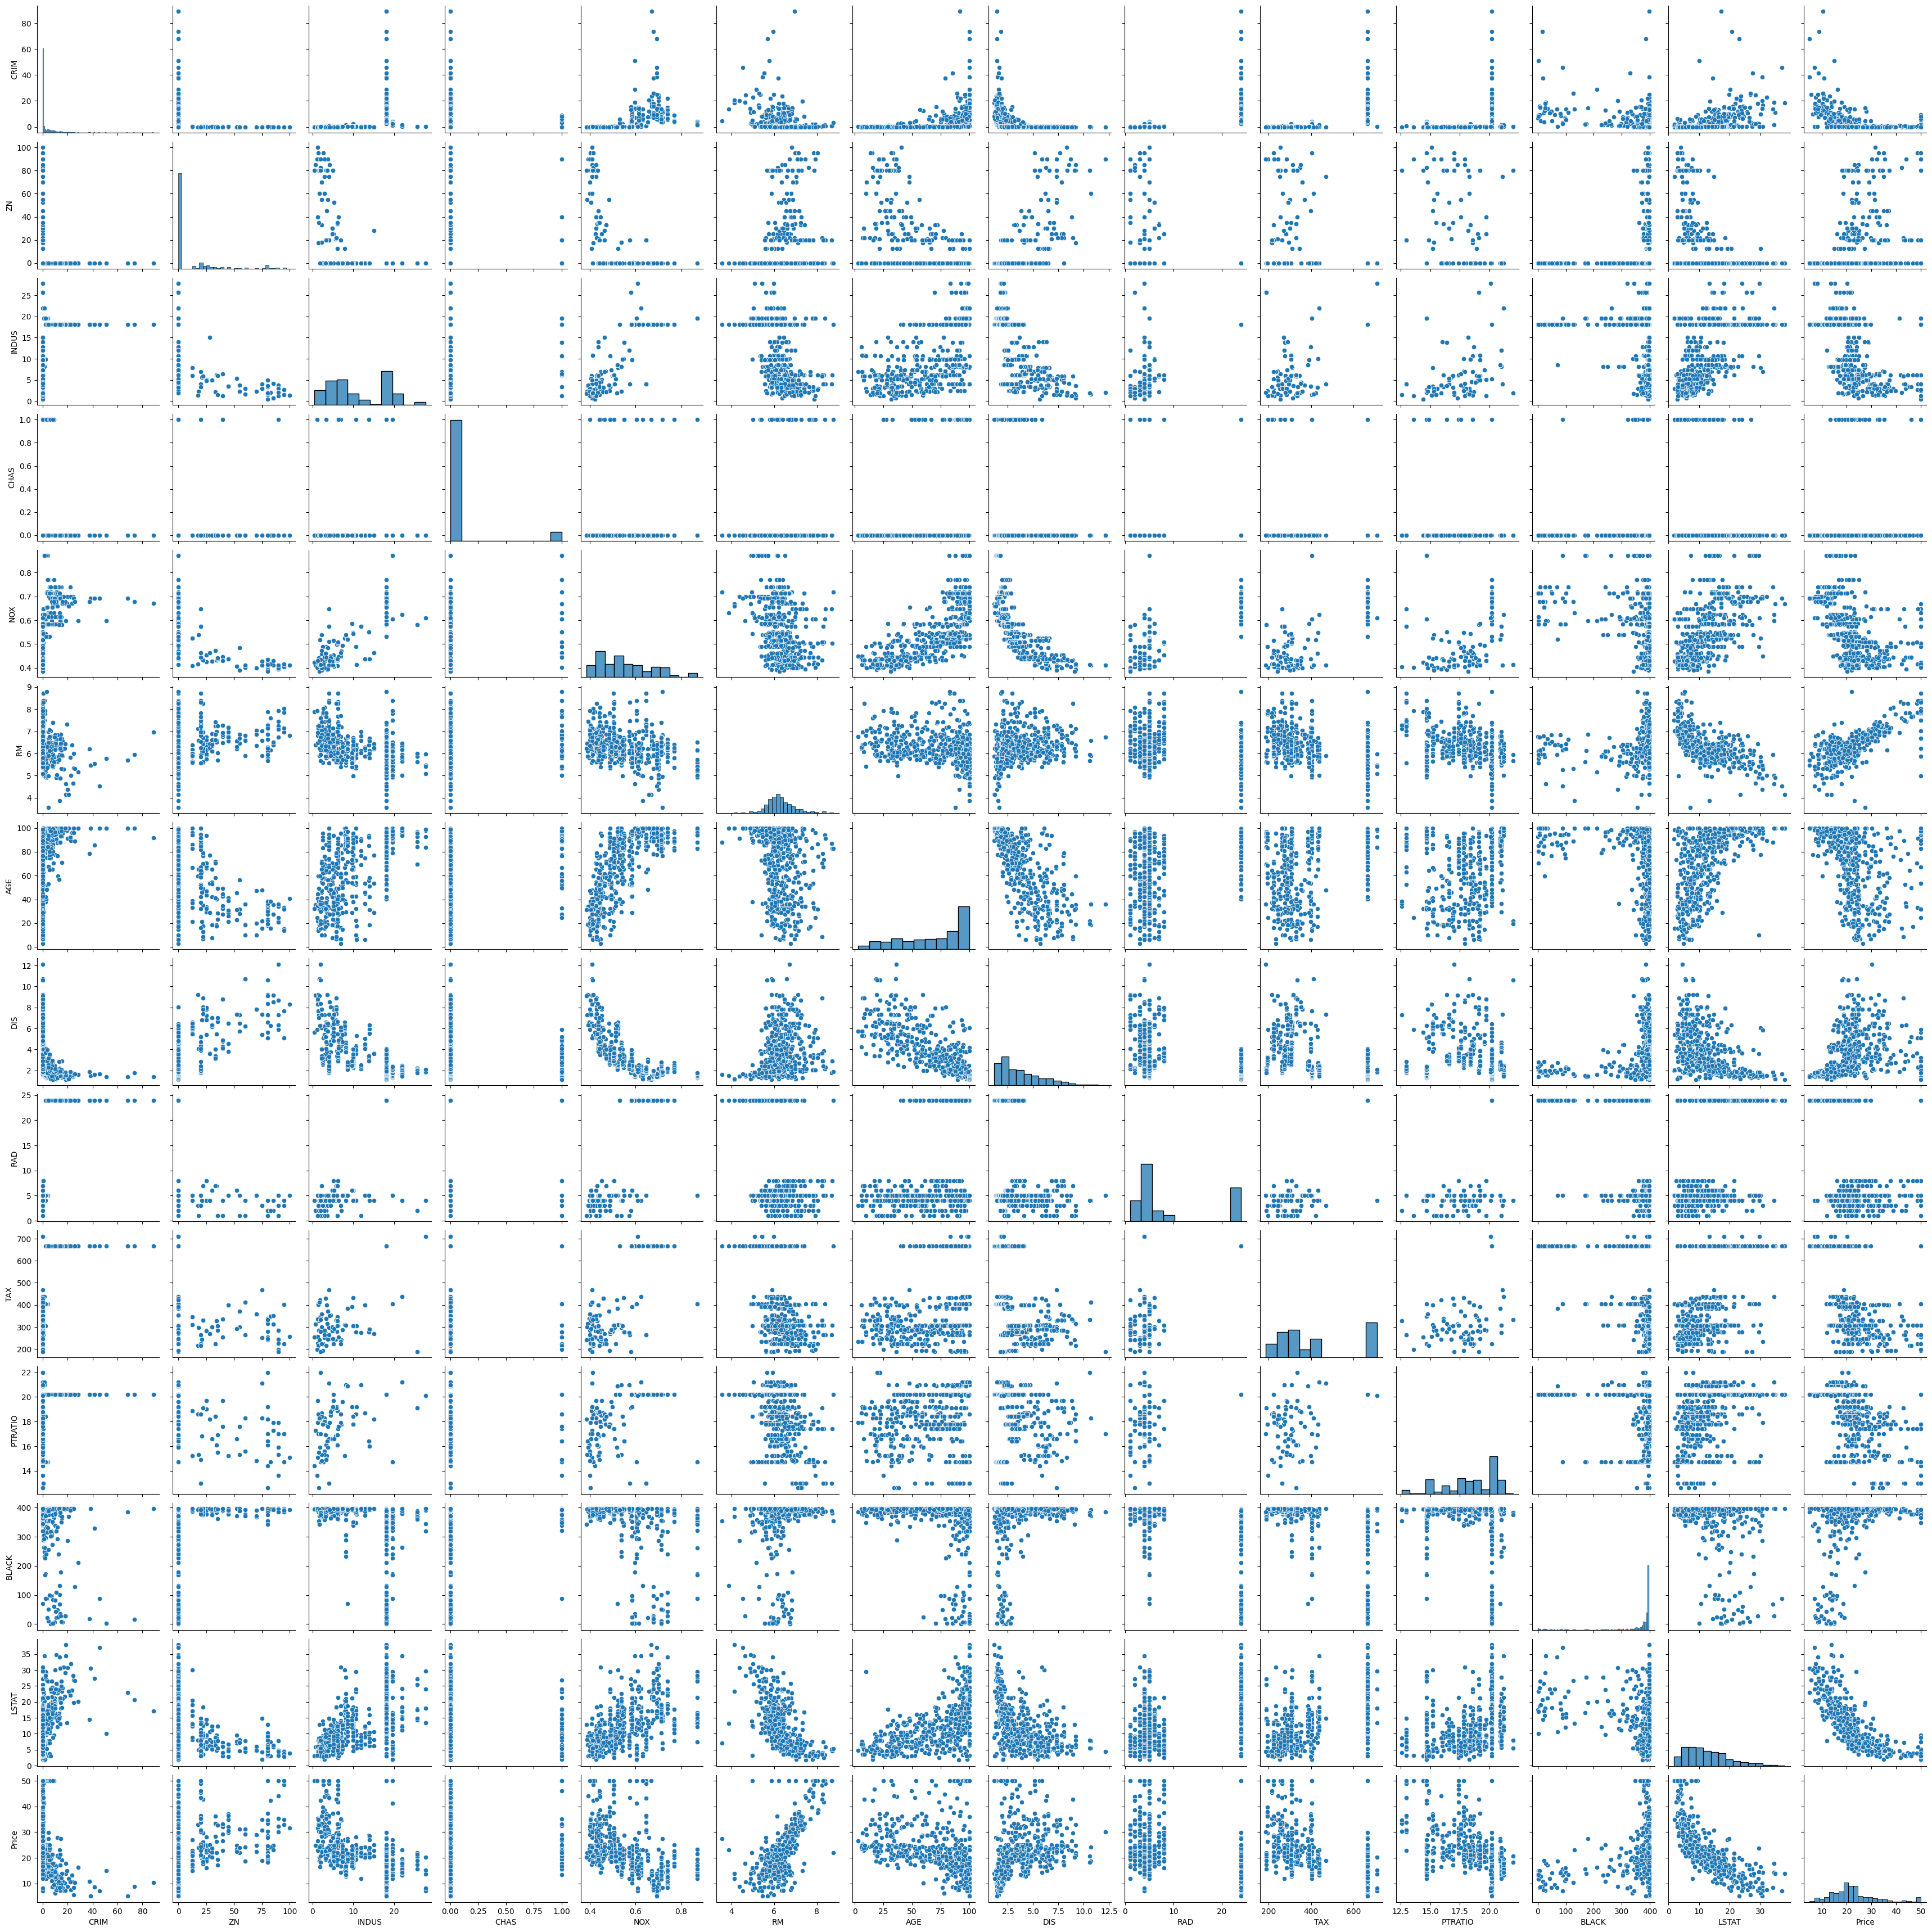

In [11]:
import seaborn as sns
sns.pairplot(dataset)

Text(0, 0.5, 'Price')

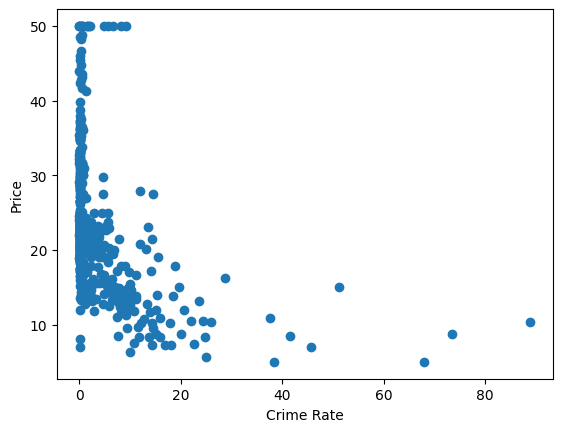

In [12]:
plt.scatter(dataset['CRIM'], dataset['Price'])
plt.xlabel("Crime Rate")
plt.ylabel("Price")

Text(0, 0.5, 'Price')

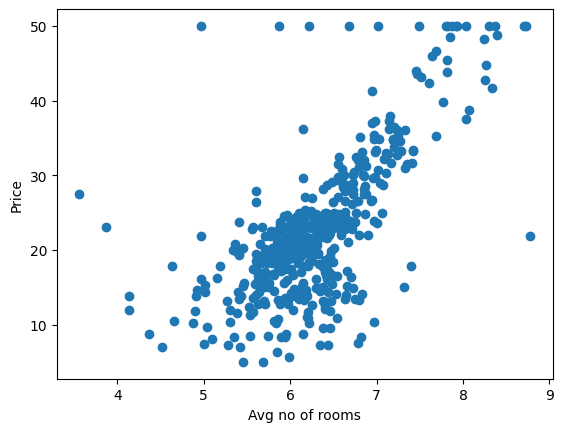

In [13]:
plt.scatter(dataset['RM'], dataset['Price'])
plt.xlabel("Avg no of rooms")
plt.ylabel("Price")

<AxesSubplot:xlabel='RM', ylabel='Price'>

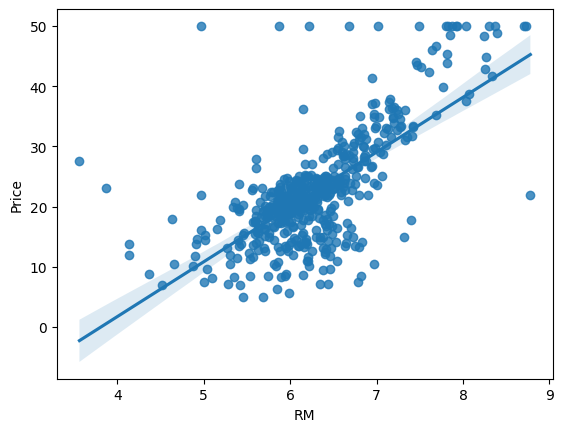

In [14]:
import seaborn as sns
sns.regplot(x="RM", y="Price", data = dataset)

<AxesSubplot:xlabel='LSTAT', ylabel='Price'>

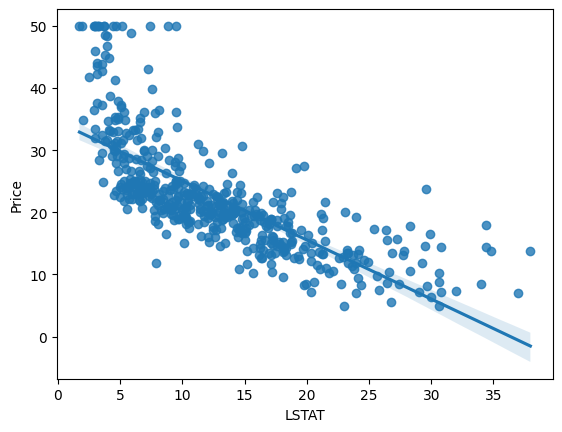

In [15]:
sns.regplot(x="LSTAT", y="Price", data = dataset)

<AxesSubplot:xlabel='CHAS', ylabel='Price'>

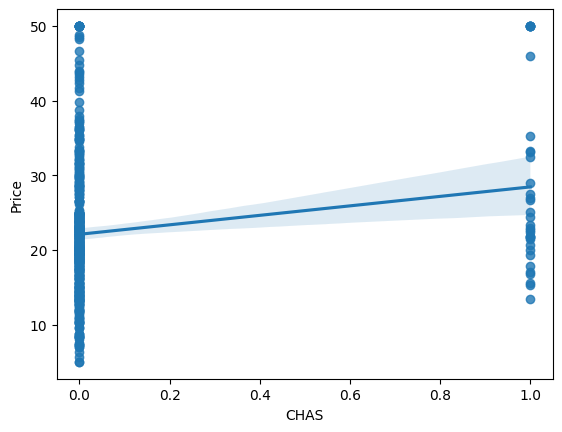

In [16]:
sns.regplot(x="CHAS", y="Price", data = dataset)

<AxesSubplot:xlabel='PTRATIO', ylabel='Price'>

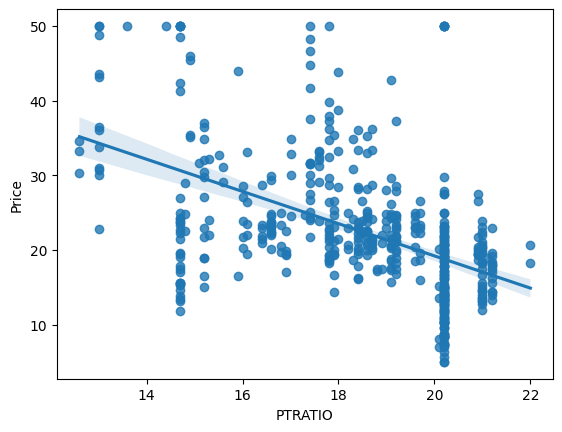

In [17]:
sns.regplot(x="PTRATIO", y="Price", data = dataset)

In [18]:
# Independent and Dependent features
X = dataset.iloc[:, :-1]
Y = dataset.iloc[:, -1]

In [19]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [20]:
Y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: Price, dtype: float64

In [21]:
# Train and Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, random_state = 111)

In [22]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
199,0.03150,95.0,1.47,0,0.403,6.975,15.3,7.6534,3,402,17.0,396.90,4.56
101,0.11432,0.0,8.56,0,0.520,6.781,71.3,2.8561,5,384,20.9,395.58,7.67
386,24.39380,0.0,18.10,0,0.700,4.652,100.0,1.4672,24,666,20.2,396.90,28.28
77,0.08707,0.0,12.83,0,0.437,6.140,45.8,4.0905,5,398,18.7,386.96,10.27
176,0.07022,0.0,4.05,0,0.510,6.020,47.2,3.5549,5,296,16.6,393.23,10.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,0.05188,0.0,4.49,0,0.449,6.015,45.1,4.4272,3,247,18.5,395.99,12.86
212,0.21719,0.0,10.59,1,0.489,5.807,53.8,3.6526,4,277,18.6,390.94,16.03
468,15.57570,0.0,18.10,0,0.580,5.926,71.0,2.9084,24,666,20.2,368.74,18.13
364,3.47428,0.0,18.10,1,0.718,8.780,82.9,1.9047,24,666,20.2,354.55,5.29


In [23]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
93,0.02875,28.0,15.04,0,0.4640,6.211,28.9,3.6659,4,270,18.2,396.33,6.21
223,0.61470,0.0,6.20,0,0.5070,6.618,80.8,3.2721,8,307,17.4,396.90,7.60
39,0.02763,75.0,2.95,0,0.4280,6.595,21.8,5.4011,3,252,18.3,395.63,4.32
122,0.09299,0.0,25.65,0,0.5810,5.961,92.9,2.0869,2,188,19.1,378.09,17.93
203,0.03510,95.0,2.68,0,0.4161,7.853,33.2,5.1180,4,224,14.7,392.78,3.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,0.80271,0.0,8.14,0,0.5380,5.456,36.6,3.7965,4,307,21.0,288.99,11.69
218,0.11069,0.0,13.89,1,0.5500,5.951,93.8,2.8893,5,276,16.4,396.90,17.92
45,0.17142,0.0,6.91,0,0.4480,5.682,33.8,5.1004,3,233,17.9,396.90,10.21
442,5.66637,0.0,18.10,0,0.7400,6.219,100.0,2.0048,24,666,20.2,395.69,16.59


In [24]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
X_train = scaler.fit_transform(X_train)

In [26]:
X_test = scaler.transform(X_test)

In [27]:
import pickle
pickle.dump(scaler,open('scaling.pkl','wb'))

##Model Training

In [28]:
from sklearn.linear_model import LinearRegression
Regression = LinearRegression()
Regression.fit(X_train, y_train)

LinearRegression()

In [29]:
## Print the coefficients
print(Regression.coef_)

[-0.81614534  1.12499027  0.22088626  0.35025065 -1.65292042  2.41398232
 -0.25168497 -2.8671151   2.18805524 -1.84883991 -1.8855167   0.90089499
 -3.7940734 ]


In [30]:
print(Regression.intercept_)

22.253954802259887


In [31]:
# On which parameters model has been trained
Regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'normalize': 'deprecated',
 'positive': False}

In [32]:
# Prediction with test data
Regression_pred = Regression.predict(X_test)

In [33]:
Regression_pred

array([ 2.95480075e+01,  2.92690014e+01,  3.20168961e+01,  2.04142235e+01,
        4.20855335e+01,  2.71728005e+01,  3.51791950e+01,  1.56376596e+01,
        2.47946863e+01,  1.40560008e+01,  2.77474462e+01,  4.32442194e+01,
        2.21508276e+01,  3.00299594e+01,  1.97723691e+01,  2.48502622e+01,
        2.47340153e+01,  2.22244317e+01,  1.36081078e+01,  1.77062485e+01,
        1.40662347e+01,  2.71705934e+01,  2.31364485e+01,  2.58227442e+01,
        7.60883406e+00,  1.95698689e+01,  3.66117271e+01,  2.49177110e+01,
        2.13656005e+01,  6.10674442e-01,  3.27700764e+01,  7.56740108e+00,
        8.98261859e+00,  2.98684356e+01,  3.76440240e+01,  2.43883129e+01,
        7.40662538e+00,  4.02538353e+01,  2.43855033e+01,  1.68852965e+01,
        2.52266551e+01,  1.87428598e+01,  1.46944539e+01,  2.30933130e+01,
        2.11992170e+01,  3.38771233e+01,  3.04446324e+01,  1.36304200e+01,
        3.08272062e+01,  1.98250145e+01,  2.36296547e+01,  2.74734092e+01,
        1.56717428e+01,  

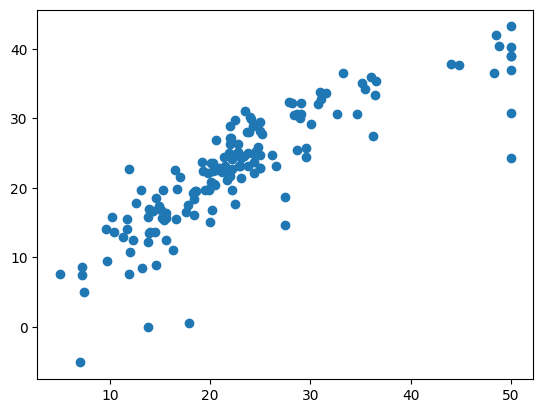

In [34]:
# Plot a scatter plot for prediction
plt.scatter(y_test, Regression_pred)

In [35]:
# Residuals
residuals = y_test - Regression_pred

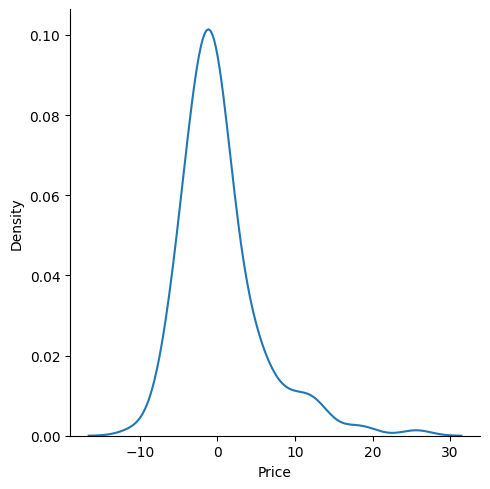

In [36]:
# Plot the residuals
sns.displot(residuals, kind="kde")

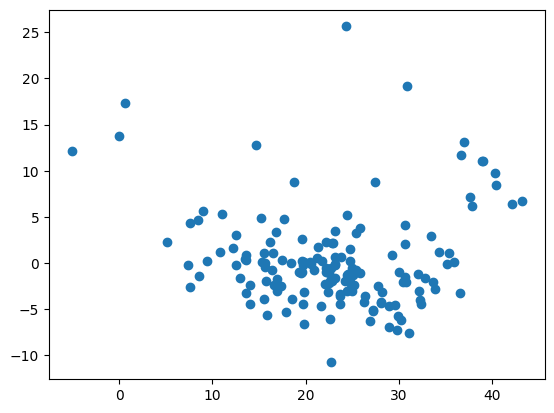

In [37]:
## Scatter plot wrt prediction and residuals
plt.scatter(Regression_pred, residuals)

In [38]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


print(mean_squared_error(y_test, Regression_pred))
print(mean_absolute_error(y_test, Regression_pred))
print(np.sqrt(mean_squared_error(y_test, Regression_pred)))

27.99960806694504
3.6062795283120535
5.29146558780694


## Formula

R^2 = 1 - SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [39]:
from sklearn.metrics import r2_score
score=r2_score(y_test,Regression_pred)
print(score)


0.7176788943158737


## Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]

where:

R2: The R2 of the model n: The number of observations k: The number of predictor variables

In [40]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6910834278383835

## Pickle the model file for deployment

In [41]:
import pickle

In [42]:
pickle.dump(Regression, open('boston_reg_model.pkl', 'wb'))

In [43]:
pickled_model = pickle.load(open('boston_reg_model.pkl', 'rb'))